In [2]:
!pip install fastai
import pandas as pd
from fastai.vision.all import *


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 92.7 MB/s eta 0:00:00:00:010:01
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0

Reading the data

In [3]:
df = pd.read_csv('/kaggle/input/datasets/nour12347653/skin-disease-detection-dataset-ham10000-isic/HAM10000_metadata.csv')
df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


Editing the values of column image_id to contain .jpg extension. so that we can use this column inside datablock for assiging the training data paths

In [4]:
df['image_id'] = df['image_id'].astype(str) + '.jpg'
df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419.jpg,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030.jpg,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769.jpg,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661.jpg,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633.jpg,bkl,histo,75.0,male,ear


Counting the total number of datas based on each label 

In [5]:
df['dx'].value_counts()

dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64

selecting 90% of datas to be used for building the skin disease classification model, as the rest 10% of datas will be used for testing.

In [6]:
df_train =df.iloc[:9013]
df_train.shape

(9013, 7)

In [7]:
path = Path('/kaggle/input/datasets/nour12347653/skin-disease-detection-dataset-ham10000-isic/processed_images_dataset/processed_images')

datablock = DataBlock(blocks=(ImageBlock, CategoryBlock),
                   splitter=RandomSplitter(valid_pct = 0.2 , seed = 42),  #splitting the datas into train and test 
                   get_x=ColReader('image_id',pref=path),   #the source of the data is the path to the image, and we are using the path as the prefix to each filepaths
                   get_y=ColReader('dx'),    #labels to identify the category of the image
                   item_tfms = [Resize(192, method = 'squish')],
                   )


Loading the data with the help of datablock

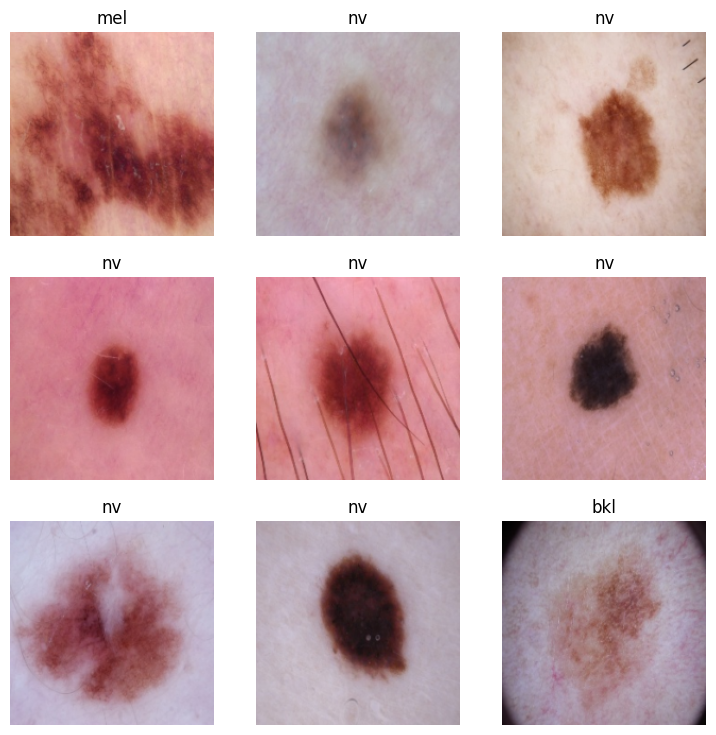

In [8]:
dls = datablock.dataloaders(df_train)
dls.show_batch()

Fine tuning the vision learner model

In [9]:
learn = vision_learner(dls,resnet18,metrics= error_rate)
learn.fine_tune(6)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 187MB/s]


epoch,train_loss,valid_loss,error_rate,time
0,1.595936,1.034209,0.301887,00:32


epoch,train_loss,valid_loss,error_rate,time
0,0.820296,0.733216,0.237514,00:20
1,0.560485,0.682209,0.202553,00:20
2,0.291868,0.660917,0.183685,00:20
3,0.120492,0.716231,0.188124,00:21
4,0.052375,0.725690,0.179245,00:22
5,0.025753,0.724222,0.182575,00:22


from the above report, we can observe that upto epoch 1, both the training as well as validation loss was decreasing but after this , the validation loss was increasing even though the training loss was decreasing, showing the sign of overfitting.

In [10]:
learn = vision_learner(dls,resnet18,metrics= error_rate)
learn.fine_tune(4)

epoch,train_loss,valid_loss,error_rate,time
0,1.595404,1.036780,0.296337,00:17


epoch,train_loss,valid_loss,error_rate,time
0,0.838955,0.661449,0.217536,00:22
1,0.497476,0.640702,0.204772,00:22
2,0.216534,0.649627,0.189234,00:22
3,0.102590,0.633516,0.180355,00:22


Prediction done by our model on test dataset, as until the row 9013, we were using the datas as training and validation dataset. So, from the row 9014, all the datas are test dataset.

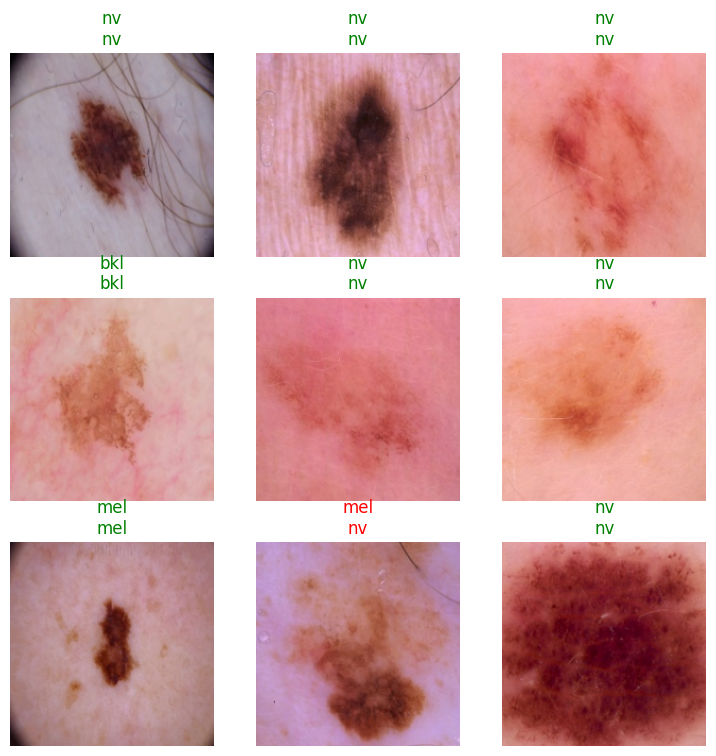

In [11]:
learn.predict(str(path) + '/' +  df.iloc[9014]['image_id'])
learn.show_results()

Plot of confusion matrix based on validation dataset

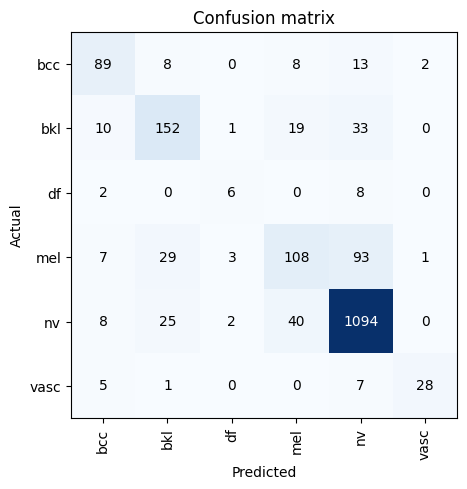

In [12]:

interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix()

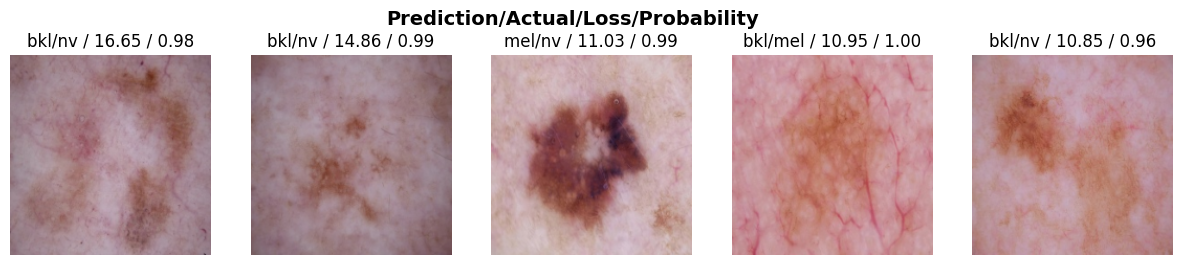

In [13]:
interp.plot_top_losses(5, nrows=1)

As we can see from the above plot of losses that the model made most of the mistakes on predicting the Melanocytic nevi disease with Benign keratosis-like lesions with high confidence level.

**cleaning the data inorder to correct the wrong predictions done by our model**

In [14]:
print([a for a in dir(interp) if not a.startswith('_')])

['act', 'confusion_matrix', 'dl', 'from_learner', 'learn', 'losses', 'most_confused', 'plot_confusion_matrix', 'plot_top_losses', 'print_classification_report', 'show_results', 'top_losses', 'vocab']


extracting the predictions which are in the form of probabilites, true class index, losses and the predicted class index

In [15]:
preds , targs , losses , decoded = learn.get_preds(with_loss=True,with_decoded = True)
#here decoded actually stores the index of the predicted class

In [16]:
first_prediction_class = dls.vocab[preds[30].argmax().item()]  #extracting the first predicted class by our model
first_true_class =  dls.vocab[targs[30].item()]
print('The first prediction class is:', first_prediction_class)
print('The first true class is:', first_true_class)

The first prediction class is: nv
The first true class is: nv


In [17]:
print('The first five prediction is:', preds[:5])
print('The first five target is:', targs[:5])



The first five prediction is: tensor([[1.7246e-05, 2.0819e-06, 1.5451e-04, 6.6039e-04, 9.9915e-01, 1.5316e-05],
        [3.6017e-05, 2.3108e-05, 8.7844e-06, 1.0550e-01, 8.9442e-01, 6.6239e-06],
        [5.0329e-05, 1.5737e-04, 5.9245e-05, 4.6398e-04, 9.9894e-01, 3.2798e-04],
        [2.8951e-05, 6.6951e-06, 2.1230e-05, 1.4579e-04, 9.9978e-01, 1.9191e-05],
        [3.2551e-05, 3.3135e-01, 3.5738e-04, 7.9302e-05, 6.6794e-01, 2.4136e-04]])
The first five target is: tensor([4, 4, 4, 4, 3])


In [18]:
losses_sorted , index = losses.sort(descending=True)  #here both losses_sorted and index will be the tensor objects
integer_index = index.tolist()  #converting the index of tensor object into list of integer, inorder to locate the datas from dataframe

here we are checking the top 20 losses, including the related predicted label and true label

In [42]:
data_indices = []
image_ids = []
predicted_labels = []
true_labels = []
for i in range(20):  #initially iterating over top 10 loss
    index = integer_index[i]  #for extraction of labels
    item = dls.valid_ds.items.iloc[index]  #extraction of the item from dataframe using .iloc
    pred_class = dls.vocab[preds[index].argmax().item()]   #we must use .argmax()  inorder to get the index of the class with highest probability and .item() to convert the tensor into int for using it in dls.vocab[]
    true_class = dls.vocab[targs[index].item()]
    
    if pred_class !=true_class:
        data_indices.append(index) 
        image_ids.append(item.image_id) 
        predicted_labels.append(pred_class) 
        true_labels.append(true_class) 
        print(f'item: {item}')        
        print('predicted class:', predicted_label)
        print('true class:', true_label)
    

item: lesion_id            HAM_0007289
image_id        ISIC_0031263.jpg
dx                           bcc
dx_type                    histo
age                         80.0
sex                         male
localization     upper extremity
Name: 2955, dtype: object
predicted class: vasc
true class: bcc


Here we are displaying the image of the skin disease that was predicted wrong by our model

This image is of bcc, which was predicted as vasc by our model


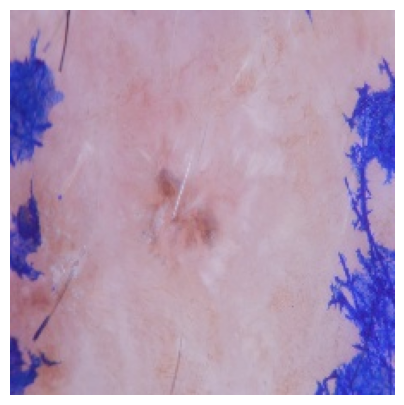

In [46]:
for image_id,predicted_label,true_label in zip(image_ids,predicted_labels,true_labels):
    img = PILImage.create(f'/kaggle/input/datasets/nour12347653/skin-disease-detection-dataset-ham10000-isic/processed_images_dataset/processed_images/{image_id}')
    img.show()
    print(f'This image is of {true_label}, which was predicted as {predicted_label} by our model')

**Now we are going to observe few images labeled as bcc and images labeled as vasc**

In [27]:
list_of_bcc_images = df.loc[df['dx'] == 'bcc','image_id'].head(5).tolist()
list_of_vasc_images = df.loc[df['dx'] == 'vasc','image_id'].head(5).tolist()


['ISIC_0031197.jpg',
 'ISIC_0031270.jpg',
 'ISIC_0029486.jpg',
 'ISIC_0031901.jpg',
 'ISIC_0032076.jpg']

In [39]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

---Images of bcc---


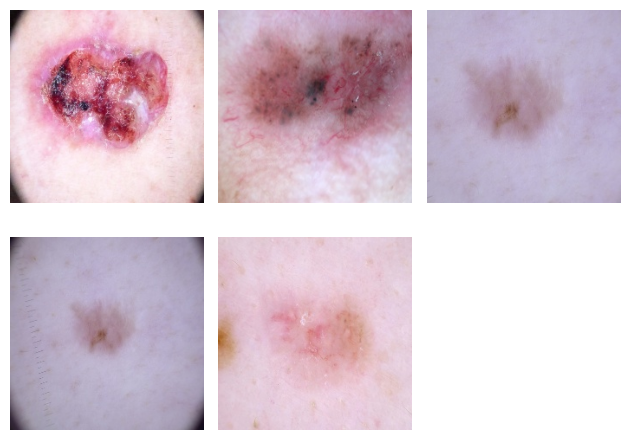

In [40]:
print('---Images of bcc---')
for i,image_id in enumerate(list_of_bcc_images):
    img_path = f'/kaggle/input/datasets/nour12347653/skin-disease-detection-dataset-ham10000-isic/processed_images_dataset/processed_images/{image_id}'
    img = PILImage.create(img_path)
    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.axis('off')
plt.tight_layout()
plt.show()
    
    

---Images of vasc---


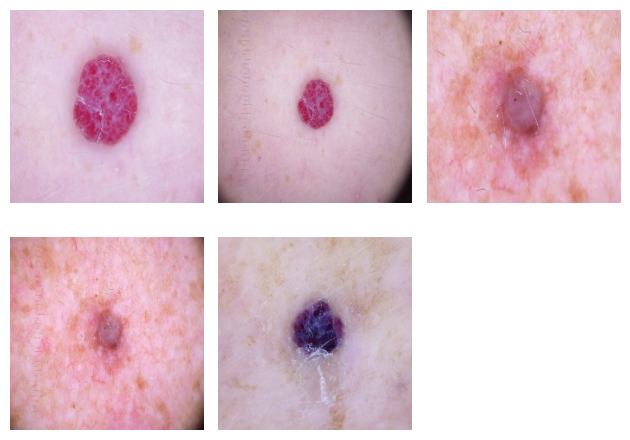

In [41]:
print('---Images of vasc---')
for i,image_id in enumerate(list_of_vasc_images):
    img_path = f'/kaggle/input/datasets/nour12347653/skin-disease-detection-dataset-ham10000-isic/processed_images_dataset/processed_images/{image_id}'
    img = PILImage.create(img_path)
    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.axis('off')
plt.tight_layout()
plt.show()
    